# Belief Activation on FinanceBench: PSRO baseline vs PSRO+TGN substrate

Compares three engines on a real FinanceBench question:

- **Baseline** (`use_tgn=False`) — PSRO + multi-agent + Bayesian 2-hop imputation. The pre-TGN production engine. Agents read signed-attention `_z`; `Graph.impute` uses the Bayesian prior.
- **TGN-pure** (`use_tgn=True`, `tgn_cold_start="pure"`) — PSRO + multi-agent unchanged. The TGN replaces the graph's representation layer: agents now read `mem_to_emb(memory)` projected to `emb_dim`, and `Graph.impute` delegates to `tgn.predict_link`. At cold start, projected memory is `mem_to_emb(zeros)` — a constant.
- **TGN-raw_fallback** (`use_tgn=True`, `tgn_cold_start="raw_fallback"`) — same as pure, except untouched nodes return their raw embedding instead of `mem_to_emb(zeros)`. Once any event fires for a node, switches to projected memory. Designed to give the agents differentiable inputs at cold start.

All three see the **same** beliefs, the **same** NLI judge, and the **same** judge budget per batch.

**The new architectural piece**: when `use_tgn=True`, `PSROLoop.step` calls `tgn.train_step(judged_events)` after the judge resolves a batch. This is what trains the TGN's link head + message encoder + GRU updater on the same judge calls that supervise the agents — turning TGN from a passive observer into a co-trained reasoner.

**First-run cost**: this notebook downloads `MiniLM-L6-v2` (~80MB) for embeddings and `DeBERTa-v3-large-mnli-fever-anli-ling-wanli` (~180MB) for NLI on first run. Subsequent runs reuse the caches.

In [1]:
%matplotlib inline
import asyncio
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from multi_agent.benchmarks import Batch
from multi_agent.config import MultiAgentConfig
from multi_agent.judge import NLIJudge
from multi_agent.runner import Trainer
from multi_agent.utils import run_sync, score_pairs
from multi_agent.utils.financebench import (
    load_financebench, make_financebench_batches, prose_questions,
)

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("torch", torch.__version__)

/Users/haripriyadhanasekaran/TGN_Belief_activation/belief_activation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.11.0


## 1. Pick a prose-heavy FinanceBench question

In [2]:
QID = "02024"

questions = load_financebench()
by_short = {q.short_id: q for q in questions}
if QID in by_short:
    question = by_short[QID]
else:
    question = prose_questions(questions, min_beliefs=15)[0]
print(f"Question: {question.short_id} \u2014 {question.company} {question.doc_period} {question.doc_type}")
print(f"  {question.question}")

Question: 02024 — Verizon 2021 10k
  As of FY 2021, how much did Verizon expect to pay for its retirees in 2024?


In [3]:
N_BATCHES = 5
EPOCHS = 2
JUDGE_BUDGET = 8

t0 = time.time()
batches = make_financebench_batches(question, n_batches=N_BATCHES, seed=SEED)
n_beliefs = sum(len(b.ids) for b in batches)
print(f"{n_beliefs} beliefs in {len(batches)} batches  ({time.time() - t0:.1f}s)")

text_of: dict[str, str] = {}
for b in batches:
    text_of.update(dict(zip(b.ids, b.texts)))

44 beliefs in 5 batches  (0.0s)


## 2. NLI judge + uniform run helper

Single shared `NLIJudge` so judge calls are deterministic across the three runs.

In [4]:
print("Loading NLI judge \u2014 first call may download DeBERTa-large\u2026")
judge = NLIJudge()
print("  ready.")

ENGINES = ["baseline", "tgn_pure", "tgn_raw_fallback"]
COLORS = {"baseline": "#4C78A8", "tgn_pure": "#F58518", "tgn_raw_fallback": "#54A24B"}

def run_engine(engine: str, seed: int = SEED, epochs: int = EPOCHS) -> dict:
    np.random.seed(seed)
    torch.manual_seed(seed)

    use_tgn = engine in ("tgn_pure", "tgn_raw_fallback")
    cold_start = "raw_fallback" if engine == "tgn_raw_fallback" else "pure"
    cfg = MultiAgentConfig(
        emb_dim=batches[0].embs.shape[1],
        num_agents=3,
        k=8,
        seed=seed,
        agent_roles={
            "agent_0": "coherence",
            "agent_1": "contradiction",
            "cosine": "semantic",
        },
        judge_budget_per_batch=JUDGE_BUDGET,
        use_tgn=use_tgn,
        tgn_cold_start=cold_start,
        tgn_memory_dim=64,
        tgn_time_dim=16,
        tgn_n_attn_heads=2,
    )
    trainer = Trainer(cfg, judge)

    per_step = []
    step_times_ms = []
    losses = []
    t_start = time.perf_counter()
    for _ in range(epochs):
        for batch in batches:
            t = time.perf_counter()
            res = trainer.step(batch)
            step_times_ms.append((time.perf_counter() - t) * 1000.0)
            per_step.append(res.stats)
            if use_tgn:
                losses.append(
                    float(trainer.loop.last_step_stats.get("tgn_loss", 0.0))
                )
            else:
                losses.append(float(res.stats.loss))
    total_s = time.perf_counter() - t_start

    edges = set(trainer.graph._edges.keys())
    nodes = trainer.graph.get_nodes()
    held_out = {}
    for i, q in enumerate(nodes):
        for c in nodes[i + 1 :]:
            if (q, c) in edges or (c, q) in edges:
                continue
            held_out[(q, c)] = float(trainer.graph.field(q, c))

    return {
        "engine": engine,
        "per_step": per_step,
        "step_times_ms": step_times_ms,
        "losses": losses,
        "total_wall_time_s": total_s,
        "held_out": held_out,
        "n_committed_edges": len(trainer.graph._edges),
    }

Loading NLI judge — first call may download DeBERTa-large…
  ready.


## 3. Run all three engines

In [5]:
results = {}
for engine in ENGINES:
    print(f"Running {engine}\u2026")
    results[engine] = run_engine(engine)
    print(
        f"  done in {results[engine]['total_wall_time_s']:.2f}s, "
        f"{results[engine]['n_committed_edges']} edges, "
        f"{len(results[engine]['held_out'])} held-out"
    )

Running baseline…


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 9813.45it/s]

  done in 7.37s, 197 edges, 752 held-out
Running tgn_pure…


  done in 4.02s, 505 edges, 441 held-out
Running tgn_raw_fallback…


  done in 3.77s, 645 edges, 302 held-out


## 4. Pair-resolution counts

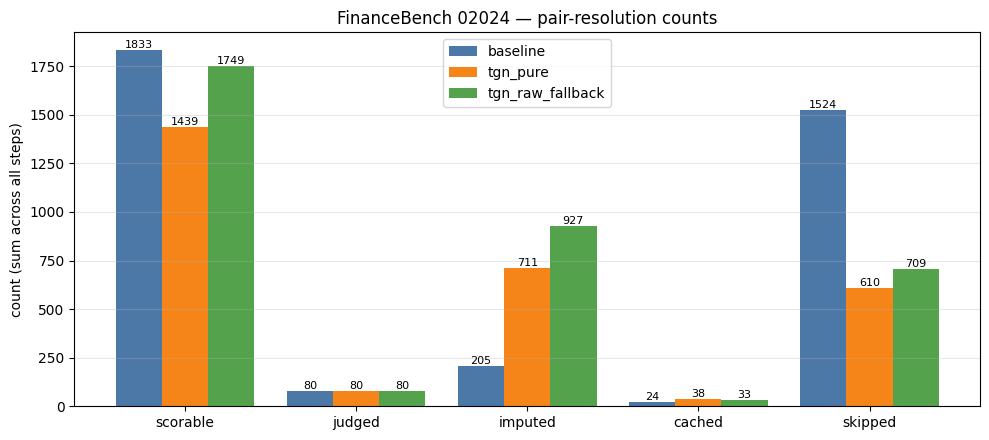

In [6]:
def total(stats, key):
    return sum(getattr(s, key) for s in stats)

metric_keys = ["scorable", "judged", "imputed", "cached", "skipped"]
data = {m: [total(results[e]["per_step"], m) for e in ENGINES] for m in metric_keys}

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(metric_keys))
w = 0.27
for i, e in enumerate(ENGINES):
    bars = ax.bar(x + (i - 1) * w, [data[m][i] for m in metric_keys], w,
                  label=e, color=COLORS[e])
    for b in bars:
        ax.annotate(f"{int(b.get_height())}",
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metric_keys)
ax.set_ylabel("count (sum across all steps)")
ax.set_title(f"FinanceBench {question.short_id} \u2014 pair-resolution counts")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Latency

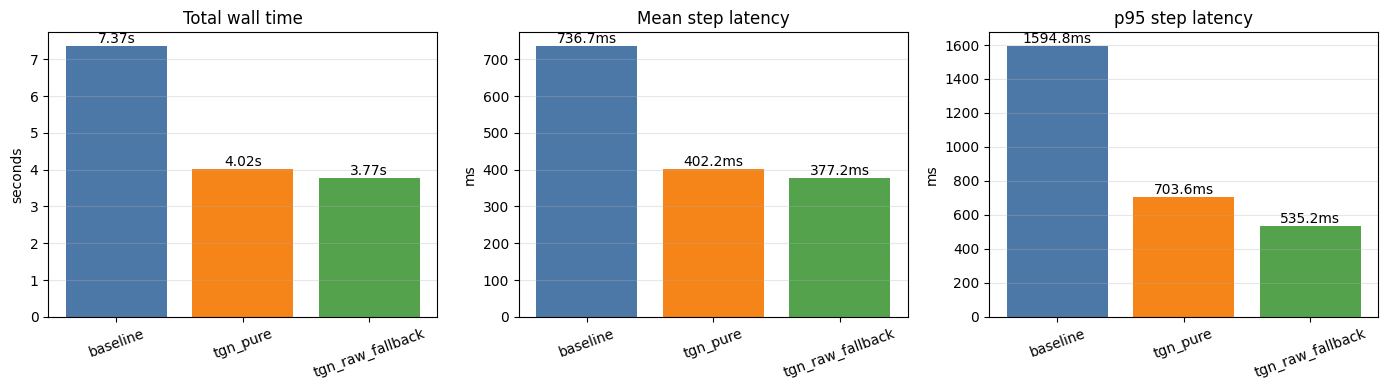

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

walls = [results[e]["total_wall_time_s"] for e in ENGINES]
axes[0].bar(ENGINES, walls, color=[COLORS[e] for e in ENGINES])
axes[0].set_title("Total wall time"); axes[0].set_ylabel("seconds")
for i, v in enumerate(walls):
    axes[0].annotate(f"{v:.2f}s", (i, v), ha="center", va="bottom")
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=20)

mean_ms = [float(np.mean(results[e]["step_times_ms"])) for e in ENGINES]
axes[1].bar(ENGINES, mean_ms, color=[COLORS[e] for e in ENGINES])
axes[1].set_title("Mean step latency"); axes[1].set_ylabel("ms")
for i, v in enumerate(mean_ms):
    axes[1].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)

p95_ms = [float(np.percentile(results[e]["step_times_ms"], 95)) for e in ENGINES]
axes[2].bar(ENGINES, p95_ms, color=[COLORS[e] for e in ENGINES])
axes[2].set_title("p95 step latency"); axes[2].set_ylabel("ms")
for i, v in enumerate(p95_ms):
    axes[2].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Per-step dynamics

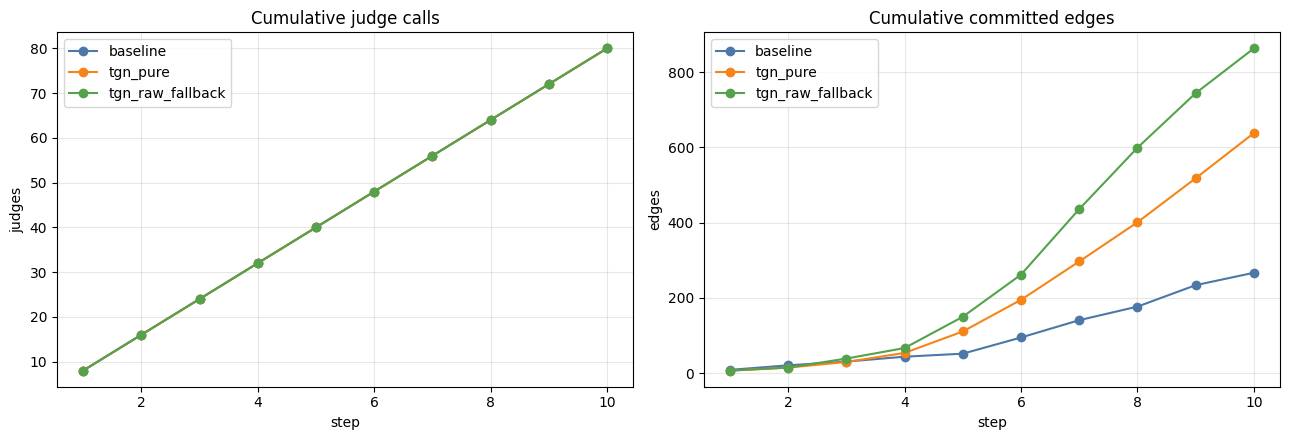

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for e in ENGINES:
    stats = results[e]["per_step"]
    judged_cum = np.cumsum([s.judged for s in stats])
    edges_cum = np.cumsum([s.n_coh + s.n_dis for s in stats])
    xs = range(1, len(stats) + 1)
    axes[0].plot(xs, judged_cum, marker="o", color=COLORS[e], label=e)
    axes[1].plot(xs, edges_cum, marker="o", color=COLORS[e], label=e)

axes[0].set_title("Cumulative judge calls"); axes[0].set_xlabel("step"); axes[0].set_ylabel("judges")
axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_title("Cumulative committed edges"); axes[1].set_xlabel("step"); axes[1].set_ylabel("edges")
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Training loss

**Baseline** reports `1 - mean reward` (REINFORCE objective). The two TGN variants report MSE between `predict_link` and the judge's revealed `y`. The two scales aren't directly comparable in absolute terms — observe direction only.

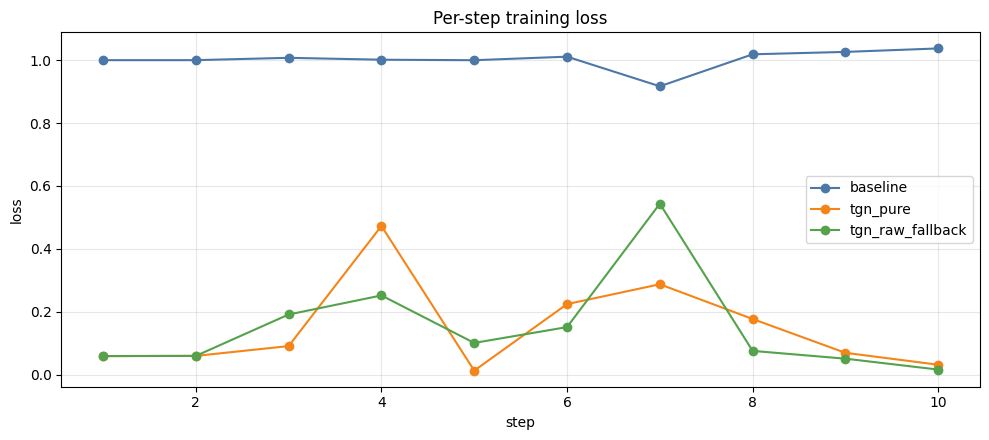

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for e in ENGINES:
    losses = results[e]["losses"]
    ax.plot(range(1, len(losses) + 1), losses, marker="o",
            color=COLORS[e], label=e)
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.set_title("Per-step training loss")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 8. NLI-graded held-out evaluation

On the **common held-out set** (pairs uncommitted by all three engines), grade with NLI as oracle and report sign accuracy + MAE per engine.

In [10]:
GT_CAP = 30

common = (
    set(results["baseline"]["held_out"])
    & set(results["tgn_pure"]["held_out"])
    & set(results["tgn_raw_fallback"]["held_out"])
)
print(f"Common held-out: {len(common)} pairs (capping NLI at {GT_CAP})")

pairs = list(common)
if len(pairs) > GT_CAP:
    rng = np.random.default_rng(SEED)
    pairs = [pairs[i] for i in rng.choice(len(pairs), size=GT_CAP, replace=False)]

text_pairs = []
for q, c in pairs:
    text_pairs.append((text_of[q], text_of[c]))
    text_pairs.append((text_of[c], text_of[q]))

t0 = time.time()
raw = run_sync(score_pairs(judge, text_pairs, concurrency=20))
ground_truth = {
    pairs[i]: float(max(raw[2 * i], raw[2 * i + 1], key=abs))
    for i in range(len(pairs))
}
print(f"  graded {len(ground_truth)} pairs via NLI in {time.time() - t0:.1f}s")

Common held-out: 142 pairs (capping NLI at 30)


  graded 30 pairs via NLI in 1.7s


In [11]:
scores = {e: {"acc": 0, "mae": 0.0} for e in ENGINES}
n = 0
for key, y_true in ground_truth.items():
    if abs(y_true) < 1e-3:
        continue
    n += 1
    for e in ENGINES:
        y_hat = results[e]["held_out"][key]
        if np.sign(y_hat) == np.sign(y_true) and abs(y_hat) > 1e-6:
            scores[e]["acc"] += 1
        scores[e]["mae"] += abs(y_hat - y_true)

if n > 0:
    print(f"NLI-graded held-out (n={n}, NLI-ambiguous pairs dropped):")
    for e in ENGINES:
        print(f"  {e:18s} sign accuracy: {scores[e]['acc']/n:.3f}   MAE: {scores[e]['mae']/n:.3f}")

NLI-graded held-out (n=27, NLI-ambiguous pairs dropped):
  baseline           sign accuracy: 0.370   MAE: 0.264
  tgn_pure           sign accuracy: 0.815   MAE: 0.308
  tgn_raw_fallback   sign accuracy: 0.815   MAE: 0.266


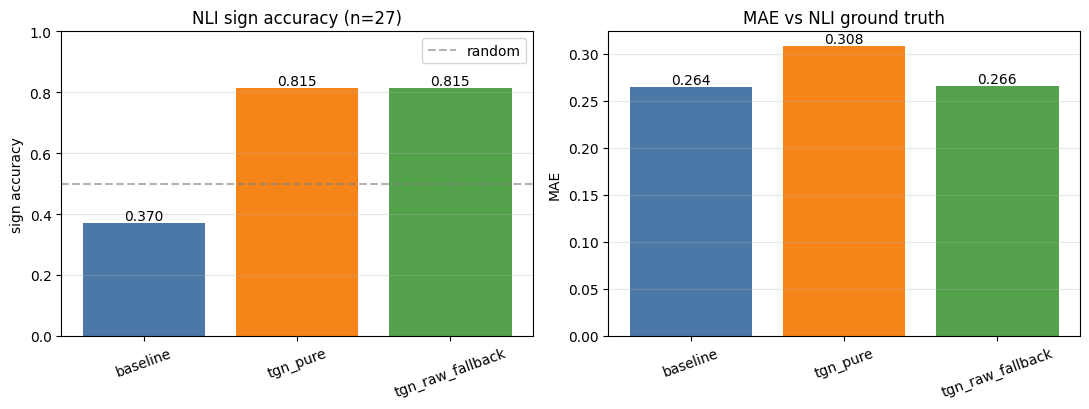

In [12]:
if n > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    accs = [scores[e]["acc"] / n for e in ENGINES]
    maes = [scores[e]["mae"] / n for e in ENGINES]

    axes[0].bar(ENGINES, accs, color=[COLORS[e] for e in ENGINES])
    axes[0].axhline(0.5, color="grey", ls="--", alpha=0.6, label="random")
    axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("sign accuracy")
    axes[0].set_title(f"NLI sign accuracy (n={n})")
    for i, v in enumerate(accs):
        axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend()

    axes[1].bar(ENGINES, maes, color=[COLORS[e] for e in ENGINES])
    axes[1].set_ylabel("MAE"); axes[1].set_title("MAE vs NLI ground truth")
    for i, v in enumerate(maes):
        axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout(); plt.show()

## 9. Summary table

In [13]:
rows = [
    ("total judge calls", lambda r: total(r["per_step"], "judged")),
    ("total imputed", lambda r: total(r["per_step"], "imputed")),
    ("total skipped", lambda r: total(r["per_step"], "skipped")),
    ("committed edges", lambda r: r["n_committed_edges"]),
    ("wall time (s)", lambda r: round(r["total_wall_time_s"], 2)),
    ("mean step (ms)", lambda r: round(float(np.mean(r["step_times_ms"])), 1)),
    ("p95 step (ms)", lambda r: round(float(np.percentile(r["step_times_ms"], 95)), 1)),
    ("held-out N", lambda r: len(r["held_out"])),
]
header = f"{'metric':<22}{'baseline':>14}{'tgn_pure':>14}{'tgn_raw_fb':>14}"
print(header); print("-" * len(header))
for name, fn in rows:
    vals = [fn(results[e]) for e in ENGINES]
    print(f"{name:<22}{str(vals[0]):>14}{str(vals[1]):>14}{str(vals[2]):>14}")

if n > 0:
    print()
    print(f"{'NLI sign acc':<22}" + "".join(
        f"{scores[e]['acc']/n:>14.3f}" for e in ENGINES))
    print(f"{'NLI MAE':<22}" + "".join(
        f"{scores[e]['mae']/n:>14.3f}" for e in ENGINES))

metric                      baseline      tgn_pure    tgn_raw_fb
----------------------------------------------------------------
total judge calls                 80            80            80
total imputed                    205           711           927
total skipped                   1524           610           709
committed edges                  197           505           645
wall time (s)                   7.37          4.02          3.77
mean step (ms)                 736.7         402.2         377.2
p95 step (ms)                 1594.8         703.6         535.2
held-out N                       752           441           302

NLI sign acc                   0.370         0.815         0.815
NLI MAE                        0.264         0.308         0.266


## What to take away

Three engines, same judge, same budget, same beliefs. The only difference is what the agents *read* and how `Graph.impute` is computed:

- **Baseline**: agents read signed-attention `_z`; `impute` uses Bayesian 2-hop posterior. The structural baseline.
- **TGN-pure**: agents read `mem_to_emb(memory)` for every node, including untouched ones (cold-start memory is zero so projected memory is a small constant). `impute` is `tgn.predict_link`.
- **TGN-raw_fallback**: same, except untouched nodes return their raw embedding so agents have differentiable inputs at cold start. Once memory has been written, switches to projected memory.

**Architectural takeaway**: with `use_tgn=True`, `PSROLoop.step` calls `tgn.train_step` after the judge, which lets gradient flow through the message encoder + GRU updater + link head together. This is the change that turns TGN from a passive observer into a co-trained reasoner.

**Run other questions**: change `QID` in cell 4 — `"01290"` Boeing, `"02416"` Pfizer. Or run from CLI:

```bash
uv run python scripts/validate_financebench.py --qid 01290 --epochs 2 --gt-cap 30
uv run python scripts/compare_baseline_vs_tgn.py --hard --seeds 5 --epochs 2
```